In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from numpy.typing import NDArray

import torch
import torch.nn as nn
import torch.optim as optim

from neural_network import NeuralNetwork
from dense_layer import DenseLayer
from activation_function import ReLU, SoftmaxCrossEntropy
from nn_pytorch import PyTorchNeuralNetwork

# Carregamento dos dados
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

X = df
y = pd.Series(data.target)

np.random.seed(42)

#### Funções auxiliares

In [22]:
def train_test_split(X: NDArray[np.float32], y: NDArray[np.float32], test_size: float = 0.2, shuffle: bool = True):
    '''
    Realiza a divisão de um dataset em parcela de treino e teste seguindo a divisão padrão de 80/20 (Respectivamente).
    Entrada:
        - X: Matriz de features (num_samples, num_features)
        - y: Vetor de rótulos (num_samples,)
        - test_size: Proporção do dataset a ser alocada para teste (default: 0.2)
    Saída:
        - X_train: Matriz de features para treino
        - X_test: Matriz de features para teste
        - y_train: Vetor de rótulos para treino
        - y_test: Vetor de rótulos para teste
    '''
    num_samples = len(y)
    
    if shuffle:
        ixs = np.random.permutation(num_samples)
        X = X.iloc[ixs]
        y = y.iloc[ixs]

    test_len = np.floor(test_size * num_samples).astype(np.int32)

    X_test = X[:test_len]
    X_train = X[test_len:]

    y_test = y[:test_len]
    y_train = y[test_len:]

    assert len(X_test) + len(X_train) == num_samples, "Dados perdidos no train_test_split (X)"
    assert len(y_test) + len(y_train) == num_samples, "Dados perdidos no train_test_split (y)"
    
    return X_train, X_test, y_train, y_test 

def to_one_hot(y, num_classes=2):
    """
    Converte rótulos (batch,) em one-hot (num_classes, batch).
    """
    y = np.asarray(y, dtype=np.int32).flatten()
    m = y.shape[0]
    Y = np.zeros((num_classes, m), dtype=np.float32)
    Y[y, np.arange(m)] = 1.0
    return Y

def get_mini_batch(X_train: NDArray[np.float32], y_train: NDArray[np.float32], batch_size: int = 32):
    """
    Recebe o dataset de treinamento, realiza shuffle aleatorio e divide em batches
    de tamanho padrão 32.
    Entrada:
        - X_train: Matriz de features para treino (num_samples, num_features)
        - y_train: Vetor de rótulos para treino (num_samples,)
    Saída:
        - mini_batches: Lista de tuplas (X_batch, y_batch) onde cada tupla contém um batch de dados
    """
    y_len = len(y_train)
    
    # Realiza permutação dos dados
    ixs = np.random.permutation(y_len)
    X = X_train.iloc[ixs]
    y = y_train.iloc[ixs]

    batches = []
    for i in range(0, len(X), batch_size):
        X_batch = X[i : i + batch_size].to_numpy().T  # (n_features, batch_size)
        y_batch = to_one_hot(y[i : i + batch_size])   # (num_classes, batch_size)

        batches.append((X_batch, y_batch))

    return batches

def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    """
    Plota a evolução da Loss e da Acurácia ao longo das épocas de treinamento.
    Entrada:
        - train_losses: Lista com os valores de loss de treino por época
        - val_losses: Lista com os valores de loss de validação por época
        - train_accs: Lista com os valores de acurácia de treino por época
        - val_accs: Lista com os valores de acurácia de validação por época
    """
    epochs = range(1, len(train_losses) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de Evolução da Loss
    axes[0].plot(epochs, train_losses, label='Treino', color='#4C72B0', marker='o', markersize=4)
    axes[0].plot(epochs, val_losses, label='Validação', color='#C44E52', marker='o', markersize=4)
    axes[0].set_title('Evolução da Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Gráfico de Evolução da Acurácia
    axes[1].plot(epochs, train_accs, label='Treino', color='#55A868', marker='o', markersize=4)
    axes[1].plot(epochs, val_accs, label='Validação', color='#E1812C', marker='o', markersize=4)
    axes[1].set_title('Evolução da Acurácia')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].set_ylim(0, 1)

    best_epoch = np.argmin(val_losses) + 1
    
    # Adicionando a marcação de Early Stopping no gráfico de Loss
    axes[0].axvline(x=best_epoch, color='black', linestyle=':', label=f'Early stop (Época {best_epoch})')
    axes[0].legend()
    
    # Adicionando a marcação de Early Stopping no gráfico de Acurácia
    axes[1].axvline(x=best_epoch, color='black', linestyle=':', label=f'Early stop (Época {best_epoch})')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def normalize(X_train: NDArray[np.float32], X_test: NDArray[np.float32]):
    media = X_train.mean(axis=0)
    desvio = X_train.std(axis=0)
    
    X_train = (X_train - media) / desvio
    X_test = (X_test - media) / desvio
    
    return X_train, X_test


##### Loop de Treinamento


In [23]:
# Mapping das features
feature_mapping = {0: "malignant", 1: "benign"}

# Número de epocas de treinamento
num_epochs = 300

# Taxa de aprendizado
lr = 0.001

# Divisão treino/validação
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size = 0.2)
X_train, X_val = normalize(X_train, X_val)

# Formato esperado pela rede: (n_features, n_samples) e (num_classes, n_samples)
X_train_np = X_train.to_numpy().T
X_val_np = X_val.to_numpy().T
y_train_oh = to_one_hot(y_train)
y_val_oh = to_one_hot(y_val)

# Prepara os tensores de avaliação do PyTorch antes do loop para maior eficiência
X_train_pt = torch.tensor(X_train_np.T, dtype=torch.float32)
y_train_pt = torch.tensor(np.argmax(y_train_oh, axis=0), dtype=torch.long)
X_val_pt = torch.tensor(X_val_np.T, dtype=torch.float32)
y_val_pt = torch.tensor(np.argmax(y_val_oh, axis=0), dtype=torch.long)

# Número de features
n_features = X_train.shape[1]

# Método de Inicialização dos pesos (pode ser "xavier", "he", "random")
initialization_method = "xavier"

# Armazena histórico de treinamento para rede implementada do zero
train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []

# Armazena histórico de treinamento para rede PyTorch
pytorch_train_loss_hist, pytorch_val_loss_hist = [], []
pytorch_train_acc_hist, pytorch_val_acc_hist = [], []


                Epoch 10/300
                Test Loss: 0.5736 / Pytorch: 0.0420, 
                Test Acc: 0.8443 / Pytorch: 0.9912 
                Val Loss: 0.5761 / Pytorch: 0.0630
                Val Acc: 0.8230 / Pytorch: 0.9735
                

                Epoch 20/300
                Test Loss: 0.4858 / Pytorch: 0.0134, 
                Test Acc: 0.9232 / Pytorch: 0.9978 
                Val Loss: 0.4931 / Pytorch: 0.0684
                Val Acc: 0.9027 / Pytorch: 0.9646
                

                Epoch 20/300
                Test Loss: 0.4858 / Pytorch: 0.0134, 
                Test Acc: 0.9232 / Pytorch: 0.9978 
                Val Loss: 0.4931 / Pytorch: 0.0684
                Val Acc: 0.9027 / Pytorch: 0.9646
                

                Epoch 30/300
                Test Loss: 0.4081 / Pytorch: 0.0058, 
                Test Acc: 0.9452 / Pytorch: 0.9978 
                Val Loss: 0.4186 / Pytorch: 0.0796
                Val Acc: 0.9381 / Pytorch: 0.9646
 

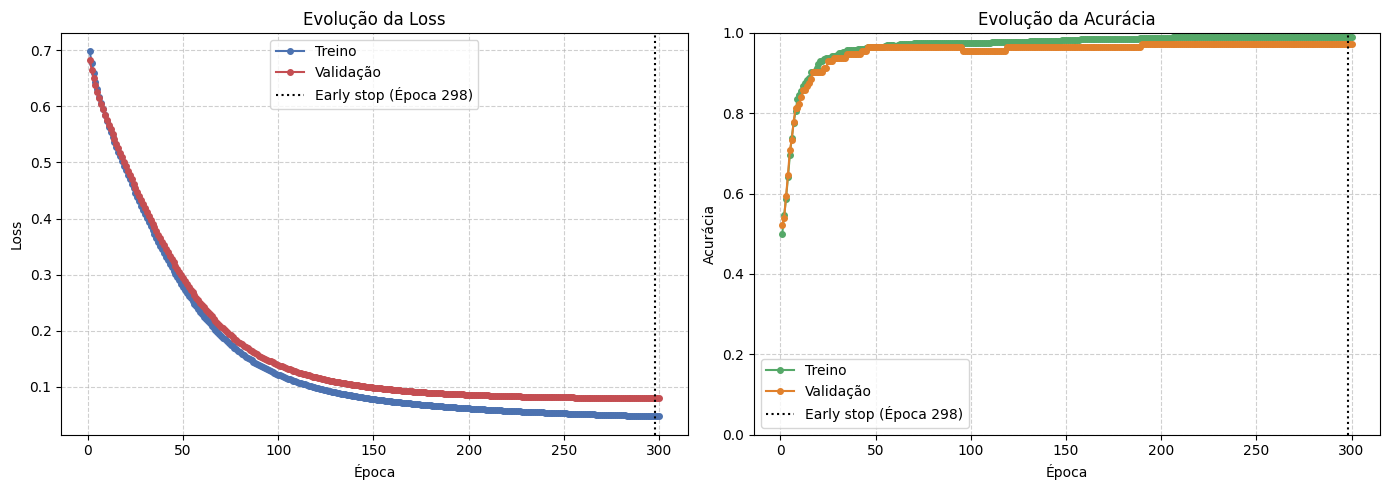

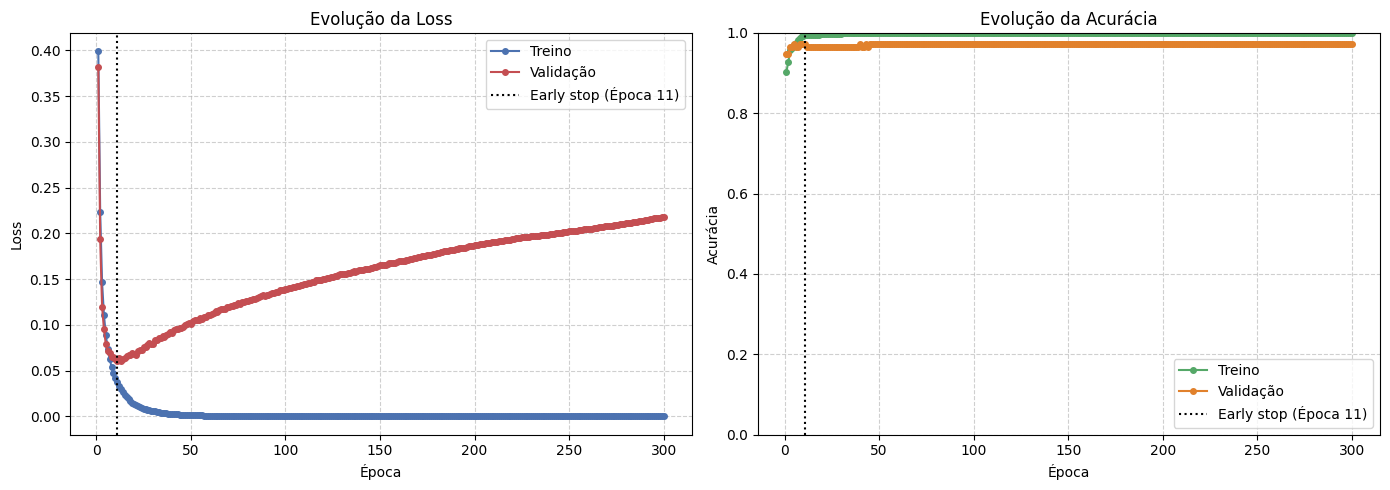

In [24]:
# Rede equilibrada do zero
layers = [ # Hidden Layers
    DenseLayer(32, n_features, ReLU(), init_method= initialization_method),
    DenseLayer(16, 32, ReLU(), init_method= initialization_method),
    DenseLayer(8, 16, ReLU(), init_method= initialization_method),
    DenseLayer(2, 8, init_method= initialization_method),  # Camada de saída [p_maligno, p_benigno]. Sem ativação pq é passada pra softmax em NeuralNetwork
]

model = NeuralNetwork(layers, SoftmaxCrossEntropy())

# Rede PyTorch
pytorch_model = PyTorchNeuralNetwork(n_features, init_method=initialization_method)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pytorch_model.parameters(), lr=lr)

# Loop de treinamento
for e in range(num_epochs):
    mini_batches = get_mini_batch(X_train, y_train, batch_size=16)
    pytorch_model.train()

    for X_batch, y_batch in mini_batches:
        # Treina o modelo implementado do zero
        model.fit(X_batch, y_batch, learning_rate=lr)

        # Treinamento PyTorch
        X_tensor = torch.tensor(X_batch.T, dtype=torch.float32)
        y_tensor = torch.tensor(np.argmax(y_batch, axis=0), dtype=torch.long)
        optimizer.zero_grad()
        outputs = pytorch_model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()

    # Calcula métricas de treino e validação
    train_loss = model.loss_activation.forward(model.predict(X_train_np), y_train_oh)
    train_preds = np.argmax(model.loss_activation.A, axis=0)
    train_acc   = np.mean(train_preds == np.argmax(y_train_oh, axis=0))
    val_loss = model.loss_activation.forward(model.predict(X_val_np), y_val_oh)
    val_preds = np.argmax(model.loss_activation.A, axis=0)
    val_acc   = np.mean(val_preds == np.argmax(y_val_oh, axis=0))

    # Calcula métricas de treino e validação para o PyTorch
    pytorch_model.eval()
    with torch.no_grad():
        pt_out_train = pytorch_model(X_train_pt)
        pt_train_loss = criterion(pt_out_train, y_train_pt).item()
        pt_train_acc = np.mean(torch.argmax(pt_out_train, dim=1).numpy() == y_train_pt.numpy())

        pt_out_val = pytorch_model(X_val_pt)
        pt_val_loss = criterion(pt_out_val, y_val_pt).item()
        pt_val_acc = np.mean(torch.argmax(pt_out_val, dim=1).numpy() == y_val_pt.numpy())

    # Armazena métricas da época atual
    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)
    
    # Armazena métricas da época atual (PyTorch)
    pytorch_train_loss_hist.append(pt_train_loss)
    pytorch_val_loss_hist.append(pt_val_loss)
    pytorch_train_acc_hist.append(pt_train_acc)
    pytorch_val_acc_hist.append(pt_val_acc)

    if (e + 1) % 10 == 0:
        print(f"""
                Epoch {e + 1}/{num_epochs}
                Test Loss: {train_loss:.4f} / Pytorch: {pt_train_loss:.4f}, 
                Test Acc: {train_acc:.4f} / Pytorch: {pt_train_acc:.4f} 
                Val Loss: {val_loss:.4f} / Pytorch: {pt_val_loss:.4f}
                Val Acc: {val_acc:.4f} / Pytorch: {pt_val_acc:.4f}
                """)
 
plot_training_history(train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist)
plot_training_history(pytorch_train_loss_hist, pytorch_val_loss_hist, pytorch_train_acc_hist, pytorch_val_acc_hist)

Classe verdadeira da instância analisada: benign

============== ANÁLISE SHAP PARA A CLASSE: MALIGNANT ==============

[Sanity Check Local] sum(SHAP)=-0.239510 vs f(x)-f(b)=-0.239510


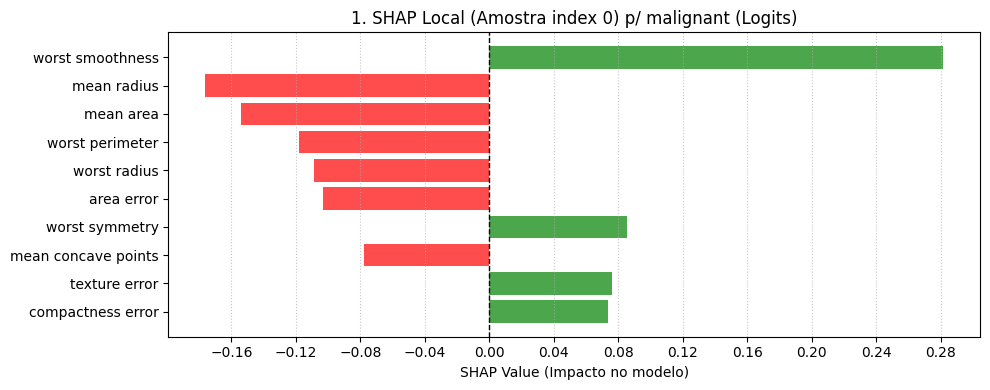

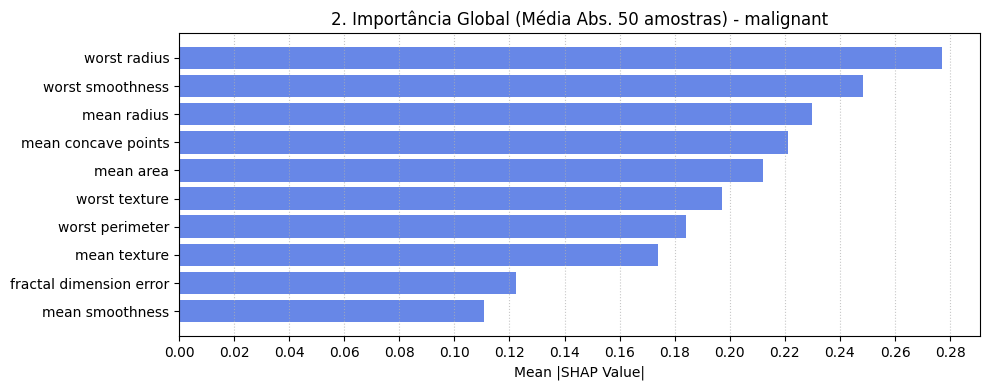

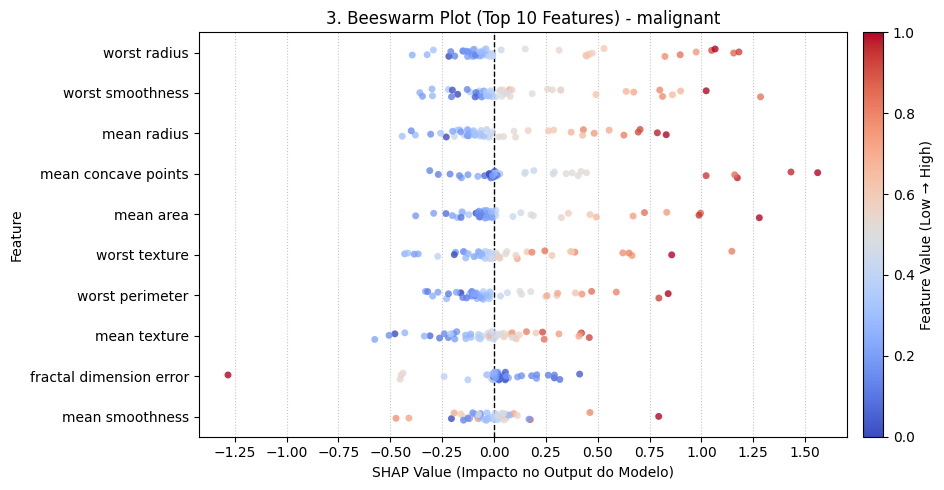


============== ANÁLISE SHAP PARA A CLASSE: BENIGN ==============

[Sanity Check Local] sum(SHAP)=0.764517 vs f(x)-f(b)=0.764517


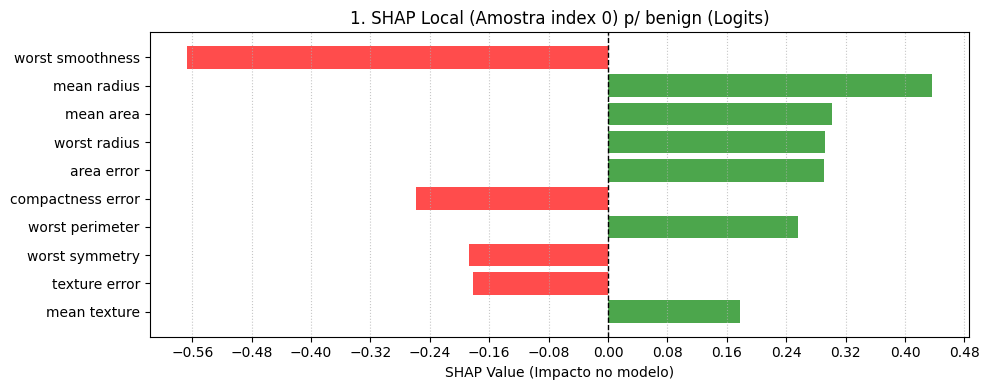

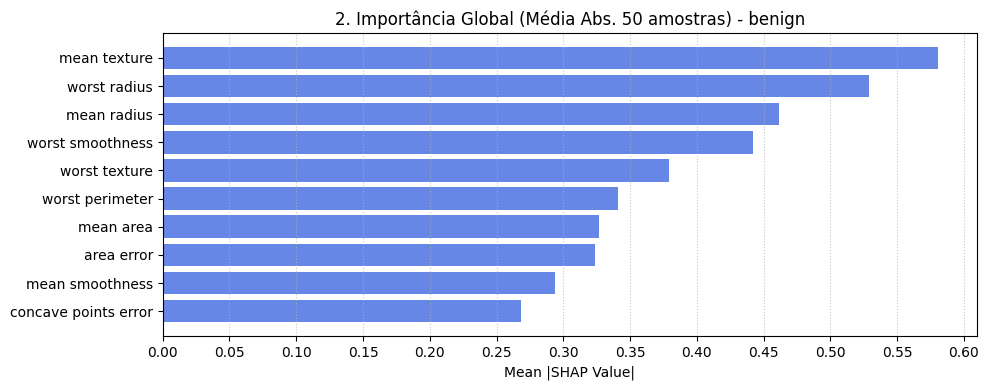

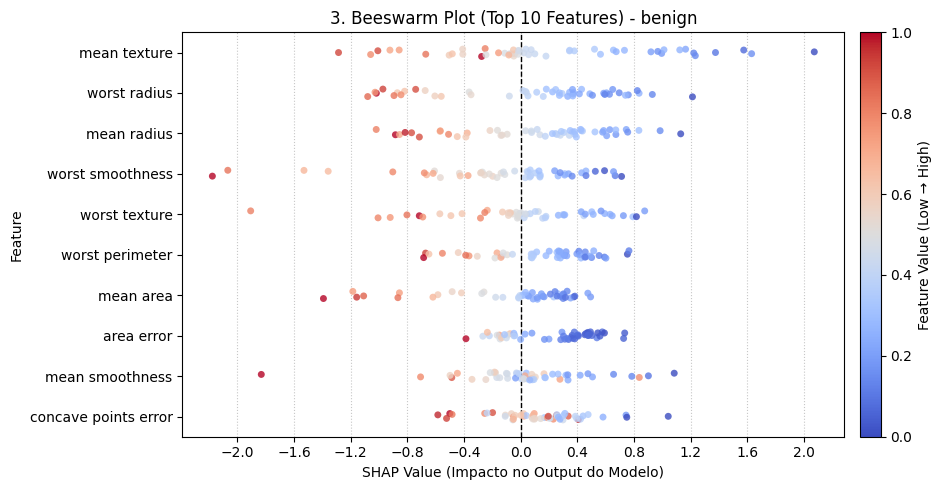

In [25]:
# O baseline escolhido será o vetor médio de todas as entradas do conjunto de treinamento
X_baseline = np.mean(X_train_np, axis=1, keepdims=True)

# Vamos explicar a primeira instância do conjunto de validação
idx_to_explain = 0
X_instance = X_val_np[:, [idx_to_explain]]  # Formato coluna (numFeatures, 1)

# Pega a classe verdadeira da instância analisada
true_class = np.argmax(y_val_oh[:, [idx_to_explain]], axis=0)[0]
print(f"Classe verdadeira da instância analisada: {feature_mapping[true_class]}")

# Classes que queremos analisar o SHAP (0: malignant, 1: benign)
target_classes = [0, 1]
num_amostras = min(50, X_val_np.shape[1])

import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Loop para fazer toda a análise para ambas as classes
for target_class in target_classes:
    print("\n" + "="*80)
    print(f"============== ANÁLISE SHAP PARA A CLASSE: {feature_mapping[target_class].upper()} ==============")
    print("="*80 + "\n")

    # ==============================================================================
    # --- ANÁLISE SHAP LOCAL (1 Instância) ---
    # ==============================================================================
    shap_values = model.explain_instance(X_instance, X_baseline, target_class=target_class)

    # --- Sanity check ---
    logits_instance = X_instance
    for layer in model.layers:
        logits_instance = layer.forward(logits_instance)
        
    logits_baseline = X_baseline
    for layer in model.layers:
        logits_baseline = layer.forward(logits_baseline)
        
    delta_f = float(logits_instance[target_class, 0] - logits_baseline[target_class, 0])
    sum_shap = float(shap_values.sum())
    print(f"[Sanity Check Local] sum(SHAP)={sum_shap:.6f} vs f(x)-f(b)={delta_f:.6f}")

    shap_values_flat = shap_values.flatten()
    feature_names = df.columns
    shap_dict = {feature_names[i]: float(shap_values_flat[i]) for i in range(len(feature_names))}

    shap_sorted = sorted(shap_dict.items(), key=lambda item: abs(item[1]), reverse=True)

    top_features = [item[0] for item in shap_sorted[:10]][::-1]
    top_values = [item[1] for item in shap_sorted[:10]][::-1]

    colors = ['green' if val > 0 else 'red' for val in top_values]

    plt.figure(figsize=(10, 4))
    plt.barh(top_features, top_values, color=colors, alpha=0.7)
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(15))
    plt.grid(axis='x', linestyle=':', alpha=0.7)
    plt.title(f'1. SHAP Local (Amostra index {idx_to_explain}) p/ {feature_mapping[target_class]} (Logits)')
    plt.xlabel('SHAP Value (Impacto no modelo)')
    plt.tight_layout()
    plt.show()

    # ==============================================================================
    # --- ANÁLISE SHAP GLOBAL E BEESWARM ---
    # ==============================================================================
    shap_values_list = []
    for i in range(num_amostras):
        x_i = X_val_np[:, [i]]
        shap_i = model.explain_instance(x_i, X_baseline, target_class=target_class)
        shap_values_list.append(shap_i)

    shap_values_stack = np.concatenate(shap_values_list, axis=1)
    global_shap_importance = np.mean(np.abs(shap_values_stack), axis=1)

    global_shap_dict = {feature_names[i]: float(global_shap_importance[i]) for i in range(len(feature_names))}
    global_shap_sorted = sorted(global_shap_dict.items(), key=lambda item: item[1], reverse=True)

    top_global_features = [item[0] for item in global_shap_sorted[:10]][::-1]
    top_global_values = [item[1] for item in global_shap_sorted[:10]][::-1]

    # Gráfico de Barras Global
    plt.figure(figsize=(10, 4))
    plt.barh(top_global_features, top_global_values, color='royalblue', alpha=0.8)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(15))
    plt.grid(axis='x', linestyle=':', alpha=0.7)
    plt.title(f'2. Importância Global (Média Abs. {num_amostras} amostras) - {feature_mapping[target_class]}')
    plt.xlabel('Mean |SHAP Value|')
    plt.tight_layout()
    plt.show()

    # Gráfico Beeswarm
    top10_feature_names = [item[0] for item in global_shap_sorted[:10]]
    top10_feature_indices = [list(feature_names).index(fname) for fname in top10_feature_names]

    X_val_used = X_val_np[:, :num_amostras]
    data_rows = []
    for i in range(num_amostras):
        for f_idx, fname in zip(top10_feature_indices, top10_feature_names):
            feature_val = X_val_used[f_idx, i]
            shap_val = shap_values_stack[f_idx, i]
            data_rows.append({"Feature": fname, "SHAP Value": shap_val, "Feature Value": feature_val})

    df_swarm = pd.DataFrame(data_rows)
    df_swarm["Feature Value (Norm)"] = df_swarm.groupby("Feature")["Feature Value"].transform(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8))

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.stripplot(
        data=df_swarm,
        x="SHAP Value",
        y="Feature",
        hue="Feature Value (Norm)",
        palette="coolwarm",
        jitter=True,
        alpha=0.8,
        size=5,
        order=top10_feature_names,
        legend=False,
        ax=ax,
    )

    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.xaxis.set_major_locator(plt.MaxNLocator(15))
    ax.grid(axis='x', linestyle=':', alpha=0.7)

    sm = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap="coolwarm")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Feature Value (Low → High)')

    ax.set_title(f'3. Beeswarm Plot (Top 10 Features) - {feature_mapping[target_class]}')
    ax.set_xlabel('SHAP Value (Impacto no Output do Modelo)')
    plt.tight_layout()
    plt.show()